In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [5]:
df['Purpose_Of_Use'].unique()

array(['Networking', 'Education', 'Entertainment', 'News'], dtype=object)

In [4]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score']

In [3]:
df.shape

(5000, 13)

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [7]:
df.duplicated().sum()

2

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

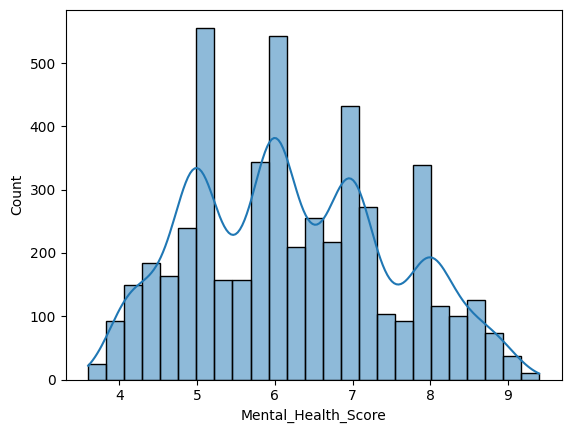

In [8]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

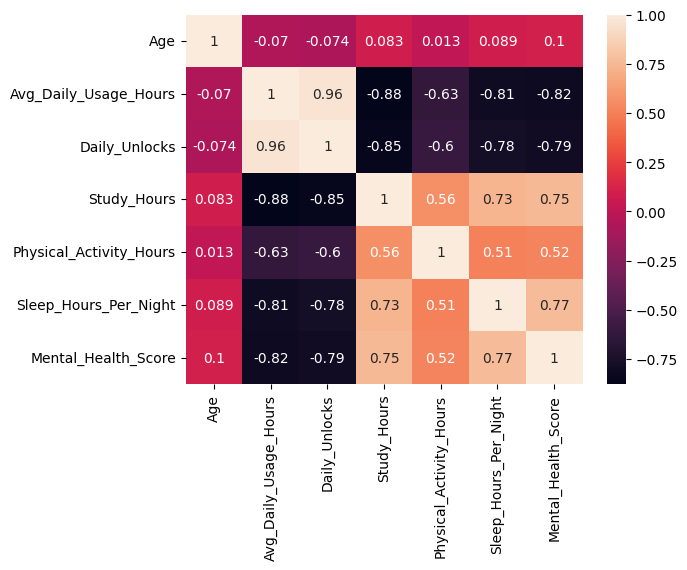

In [9]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [10]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Mental_Health_Score', ylabel='Stress_Level'>

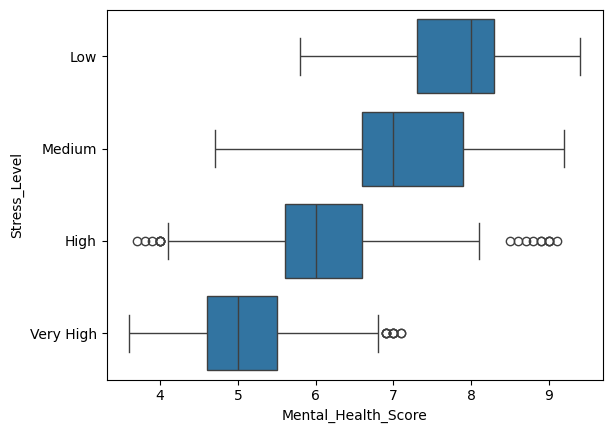

In [11]:
order=['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x=df['Mental_Health_Score'],y=df['Stress_Level'],order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

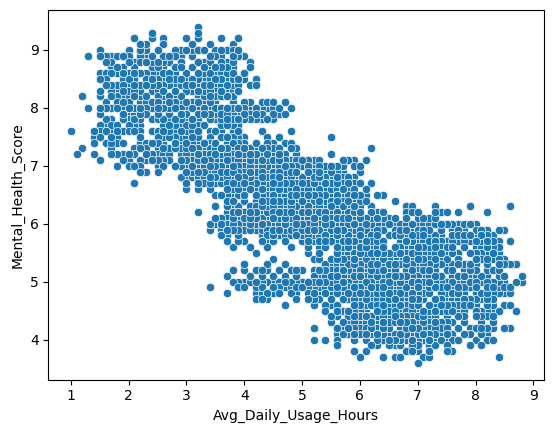

In [12]:
sns.scatterplot(x=df['Avg_Daily_Usage_Hours'],y=df['Mental_Health_Score'])

<Axes: xlabel='count', ylabel='Most_Used_Platform'>

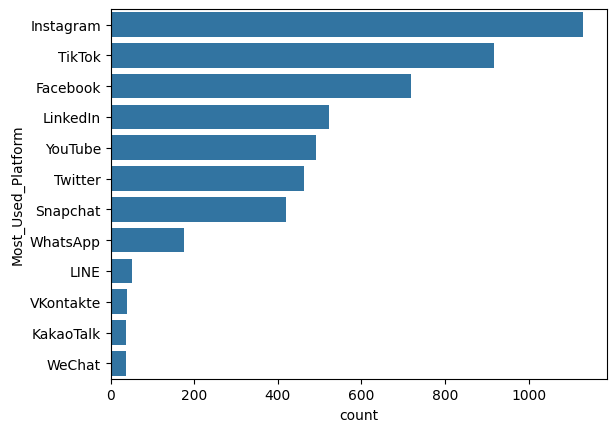

In [13]:
sns.countplot(y=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)

In [14]:
num_feature=df.select_dtypes(include='number')

In [15]:
q1=num_feature.quantile(0.25)
q3=num_feature.quantile(0.75)
iqr=q3-q1

In [16]:
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

In [17]:
outliers=(num_feature<lower_bound) | (num_feature>upper_bound)

In [18]:
outliers.sum()

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

In [19]:
df=df.drop_duplicates()

In [20]:
df.duplicated().sum()

0

In [21]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [22]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

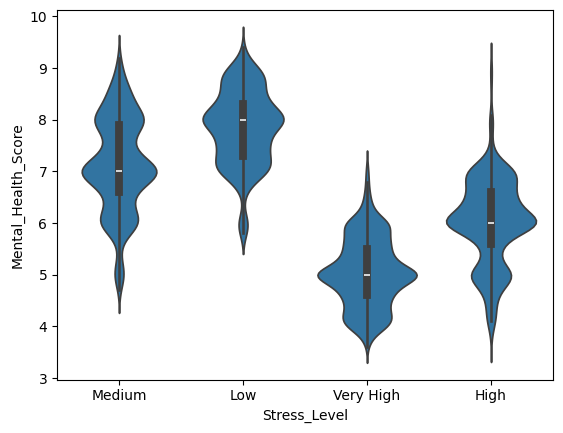

In [23]:
sns.violinplot(x=df['Stress_Level'],y=df['Mental_Health_Score'])

In [24]:
num_feature.skew()

Age                        0.155325
Avg_Daily_Usage_Hours      0.005606
Daily_Unlocks              0.002351
Study_Hours                0.435819
Physical_Activity_Hours    0.039971
Sleep_Hours_Per_Night      0.124050
Mental_Health_Score        0.206567
dtype: float64

In [25]:
num_feature.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

In [3]:
top_countries=df['Country'].value_counts().index[:10].tolist()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Turkey',
 'Mexico',
 'France']

In [27]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [28]:
df['Grouped_country']=df['Country'].apply(group_countries)

In [29]:
df['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [30]:
skews_col=['Study_Hours']
other_numeric_cols=['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_col=['Stress_Level']
normal_cols=['Gender','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Grouped_country']
feature_col=skews_col+other_numeric_cols+ordinal_col+normal_cols
x=df[feature_col]
y=df['Mental_Health_Score']

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
skew_pipeline=Pipeline(steps=[('log_transform',FunctionTransformer(np.log1p)),
                              ("scale",StandardScaler())])

plain_numeric_pipeline=Pipeline(steps=[("scale",StandardScaler())])

ordinal_pipeline=Pipeline(steps=[('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))])

normal_pipeline=Pipeline(steps=[('encode',OneHotEncoder(handle_unknown='ignore'))])


preprocessor=ColumnTransformer(transformers=[
    ('skew',skew_pipeline,skews_col),
    ('plain',plain_numeric_pipeline,other_numeric_cols),
    ('ordinal',ordinal_pipeline,ordinal_col),
    ('normal',normal_pipeline,normal_cols)
])

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
lr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])
lr_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skew',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('plain',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('encode',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('normal',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Grouped_country'])])),
                ('regressor', LinearRegression())])

In [36]:
lr_pred=lr_pipeline.predict(x_test)

In [37]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [38]:
print(r2_score(y_test,lr_pred))

0.742812906901333


In [39]:
print(r2_score(y_train,lr_pipeline.predict(x_train)))

0.7255672449830839


In [41]:
rf_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('randomforest',RandomForestRegressor(random_state=42))
])

In [40]:
from sklearn.ensemble import RandomForestRegressor

In [42]:
rf_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skew',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('plain',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('encode',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('normal',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Grouped_country'])])),
                ('randomforest', RandomForestRegressor(random_state=42))])

In [43]:
rf_pred=rf_pipeline.predict(x_test)

In [44]:
print(r2_score(y_test,rf_pred))

0.8901510306606107


In [45]:
print(r2_score(y_train,rf_pipeline.predict(x_train)))

0.9827094985154842


In [46]:
print(mean_absolute_error(y_test,rf_pred))

0.326722280952381


In [55]:
param_grid={
    'randomforest__n_estimators':[100,200,300],
    'randomforest__max_depth':[5,10,15],
    'randomforest__min_samples_split':[2,5,10],
    'randomforest__min_samples_leaf':[1,2,4]
}

In [56]:
from sklearn.model_selection import RandomizedSearchCV

In [57]:
random_search=RandomizedSearchCV(estimator=rf_pipeline,param_distributions=param_grid,n_iter=15,cv=5,scoring='r2',random_state=42,n_jobs=-1)

In [59]:
random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Physical_Activity_Hou...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('randomforest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'randomforest__max_depth': [5, 10, 15],
                                        'randomforest__min_samples_leaf': [1, 2,
                                                                           4],
                                        'randomforest__min_samples_split': [2,
                                                                            5,
                                                                            10],
                                        'randomforest__n_estimators': [100, 200,
                                                                       300]},
                   random_state=42, scoring='r2')

In [60]:
print(r2_score(y_test,random_search.best_estimator_.predict(x_test)))

0.8759087900091959


In [61]:
print(r2_score(y_train,random_search.best_estimator_.predict(x_train)))

0.9563975688440292


In [63]:
print(mean_absolute_error(y_test,random_search.best_estimator_.predict(x_test)))

0.35327760771480154


In [64]:
import joblib

In [65]:
joblib.dump(rf_pipeline,'mental_health_model.pkl')

['mental_health_model.pkl']